In [1]:
import os, sys
import json
from pathlib import Path
from importlib import reload

import matplotlib.pyplot as plt
import base64
import io

import random
import pandas as pd
import PIL

from transformers import AutoTokenizer

hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")

WORK_DIR = Path.cwd().parent

sys.path.append(str(WORK_DIR))
sys.path.append(str(WORK_DIR / "src/misc"))
from src import (
    main,
    datasets,
    video_tools,
    ollama_manager,
    prompt_formatters as pf,
)
from src.STAR_utils.visualization_tools import qa_visualization as qaviz


In [16]:
import src.misc.VCG_100_originale as vcg

In [2]:
STAR_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


In [3]:
star_small_df = None
with open(STAR_SMALL) as f:
    star_small_df = pd.read_json(f)

star_small_df = star_small_df.drop_duplicates(subset=['question_id'])
star_small_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question_id       1048 non-null   object 
 1   question          1048 non-null   object 
 2   video_id          1048 non-null   object 
 3   start             1048 non-null   float64
 4   end               1048 non-null   float64
 5   answer            1048 non-null   object 
 6   question_program  1048 non-null   object 
 7   choices           1048 non-null   object 
 8   situations        1048 non-null   object 
dtypes: float64(2), object(7)
memory usage: 73.8+ KB


In [27]:
import matplotlib.pyplot as plt
import math

def plot_frames(frames, cols=10, figsize=(15, 15), title=None):
    """
    Plot a list of PIL Image frames in a grid.

    Parameters:
    - frames (list): List of PIL.Image.Image objects.
    - cols (int): Number of columns in the grid. Defaults to 10.
    - figsize (tuple): Size of the overall figure. Defaults to (15, 15).
    - title (str): Optional title for the figure.
    """
    num_frames = len(frames)
    cols = min(cols, num_frames)
    rows = math.ceil(num_frames / cols)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for ax in axes[num_frames:]:
        ax.axis('off')

    for i, frame in enumerate(frames):
        axes[i].imshow(frame)
        axes[i].axis('off')

    if title:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()

# Example usage:
# frames = load_frames_from_folder("path/to/frames")
# plot_frames(frames, cols=10, figsize=(20, 10), title="Video Frames Grid")

# Expose the function for use
plot_frames

<function __main__.plot_frames(frames, cols=4, figsize=(15, 15), title=None)>

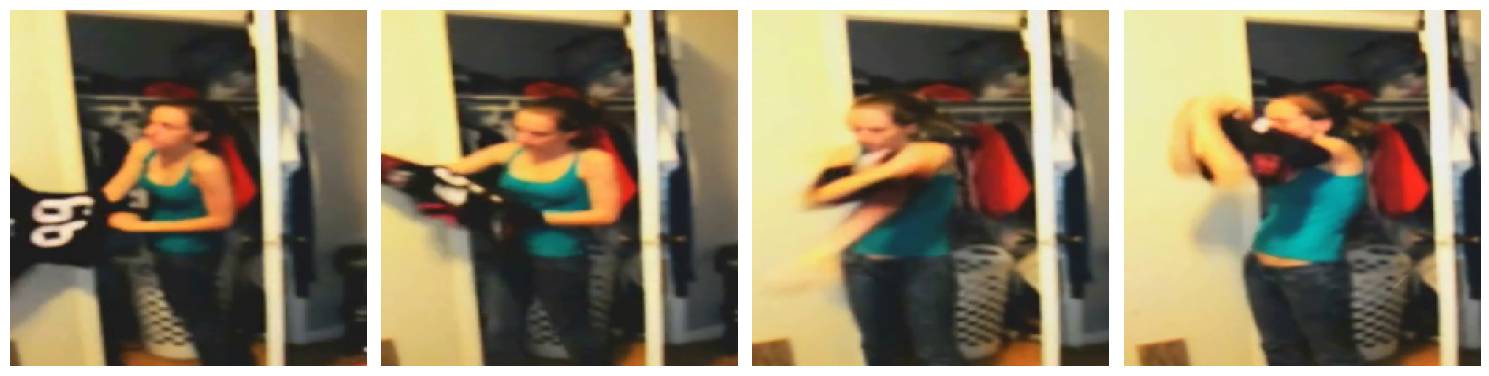

In [28]:
sample = star_small_df.iloc[0]
dir, frame_paths = video_tools.extract_frames(Path(RAW_VIDEO_DIR, f"{sample['video_id']}.mp4"), start_time=sample.get('start', None), end_time=sample.get('end', None))
frames = vcg.load_frames_from_folder(dir)
plot_frames(frames)

In [4]:
fps = 1
sample = star_small_df.iloc[0]
b64_frames = video_tools.generate_video_frames(
    Path(RAW_VIDEO_DIR, f"{sample['video_id']}.mp4"),
    fps=fps,
    start=sample.get('start', None),
    end=sample.get('end', None),
)
b64_frames


=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/ATV2F.mp4 with start: 0.0, end: 4.0, fps: 1, max_frames: None


[{'frame_id': 0,
  'encoding': '...'},
 {'frame_id': 1,
  'encoding': '...'},
 {'frame_id': 2,
  'encoding': '...'},
 {'frame_id': 3,
  'encoding': '...'}]

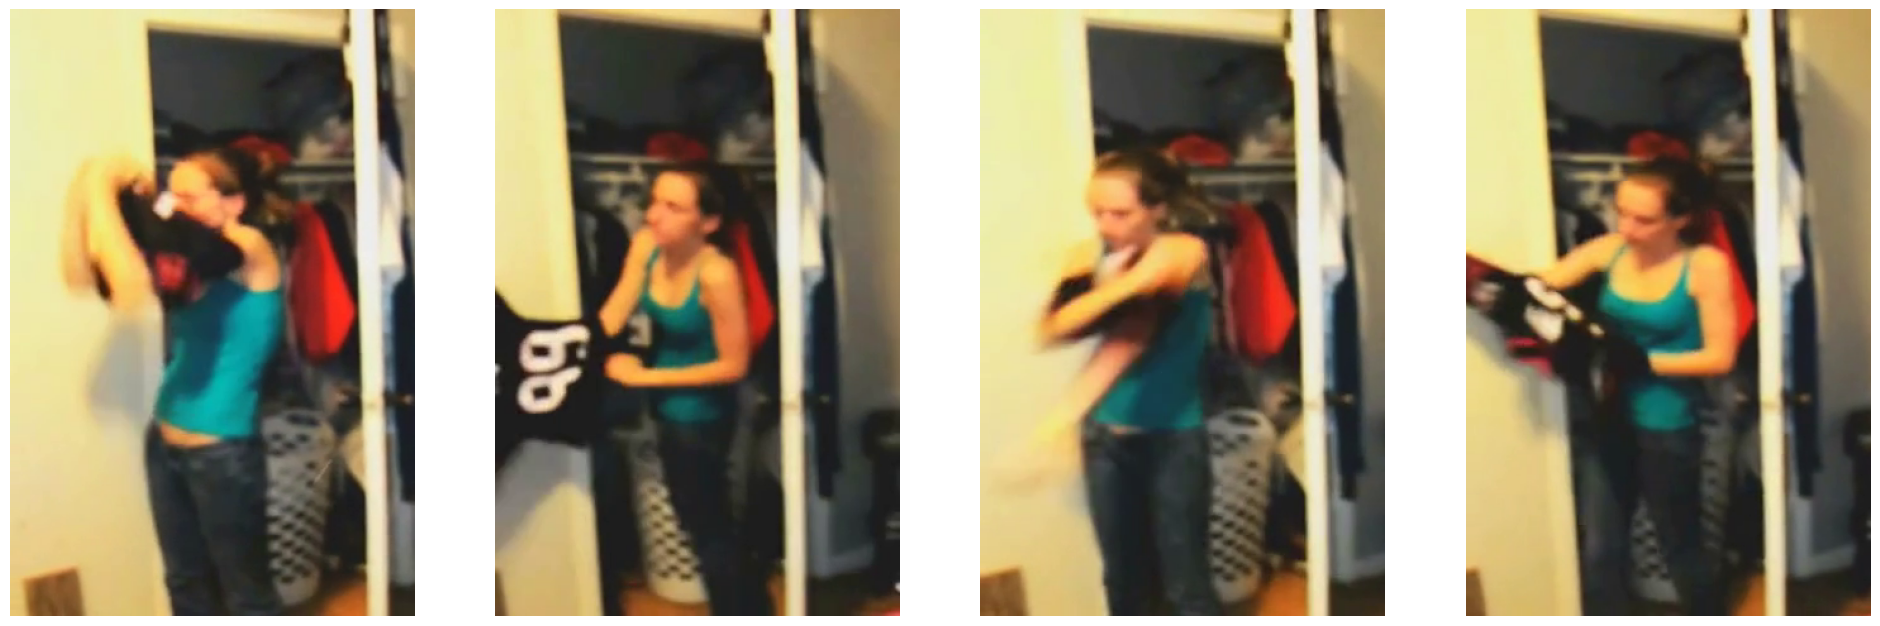

In [5]:
encodings = [frame['encoding'] for frame in b64_frames]

_, axs = plt.subplots(1, len(encodings), figsize=(24,8))

for img, ax in zip(encodings, axs):
    img = base64.b64decode(img)
    image = PIL.Image.open(io.BytesIO(img))
    image_np = np.array(image)  # Convert to NumPy array for Matplotlib
    ax.imshow(image_np)
    ax.axis('off')

plt.axis('off')  # Hide axes
plt.show()


In [6]:
# sys_file_path = WORK_DIR / "data/prompts/graph-gen/system_prompt.txt"
# sys_prompt = frames_tools._load_prompt_fromfile(sys_file_path)

model = "gemma3:4b-it-qat"
# model_options = _load_model_options()
ollama_params = {
    "model": model,
    "system": None,
    "stream": True,
    "options": {
        "num_ctx": 10240,
        "temperature": 0.1,
        "num_predict": 1024,
        "seed": 42,
    },
}

url = os.environ.get("OLLAMA_URL", "http://lusha_ollama:11435")
client = ollama_manager.OllamaRequestManager(url, ollama_params)


In [7]:
reload(ollama_manager)


<module 'src.ollama_manager' from '/home/lusha/star_code/src/ollama_manager.py'>

In [8]:
# pre-load the model
client.generate_completion("hello")


Hello there! How can I help you today? 😊 

Do you want to:

*   Ask me a question?
*   Start a conversation?
*   Have me write something (like a poem, story, or code)?
*   Just chat?

Response at: 54.0 tk/s


{'content': 'Hello there! How can I help you today? 😊 \n\nDo you want to:\n\n*   Ask me a question?\n*   Start a conversation?\n*   Have me write something (like a poem, story, or code)?\n*   Just chat?',
 'role': 'assistant'}

In [6]:
user_prompt = main._load_prompt_fromfile(WORK_DIR / "data/prompts/vqa/user_prompt_v2.txt")
follow_up = main._load_prompt_fromfile(WORK_DIR / "data/prompts/graph-gen/q-bias/format_instructions.txt")
pformatter = pf.OpenEndedPrompt(user_prompt)
star_dataset = datasets.STARDataset(
    STAR_SMALL,
    pformatter
)



Dataset Statistics:
QA File: STAR_val_small_1000.json
Number of QA samples: 1048
QA sample keys: question_id, question, video_id, start, end, answer, question_program, choices, situations



In [ ]:
star_dataset[0]['prompt']

ValueError: Missing required format fields: c1, c2, c3, c4

In [7]:
samples = [star_dataset[i] for i in range(3)]


ValueError: Missing required format fields: c1, c2, c3, c4

In [11]:
print(samples[0]['prompt'])


You are an intelligent video comprehension model. You will receive as input:
- A sequence of images (frames) extracted from a video
- A question about the video

Your task is not to answer the question but to analyze and describe the scene in enough detail such that your description alone is enough to answer the question, even if the images themselves are not available.
In generating your description, follow these guidelines:


1. Look for recurring objects;
2. Note that the same object may look different across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interact with its environment;
4. Understand the directional movement of the people and objects;
5. Carefully analyze the chronological sequence of the events;
6. Pay attention to the atomic and fine-grained movement, pose and ac

=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/ATV2F.mp4 with start: 0.0, end: 4.0, fps: 1, max_frames: None
=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/9J166.mp4 with start: 9.9, end: 17.5, fps: 1, max_frames: None
=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/ANA5N.mp4 with start: 4.3, end: 10.3, fps: 1, max_frames: None


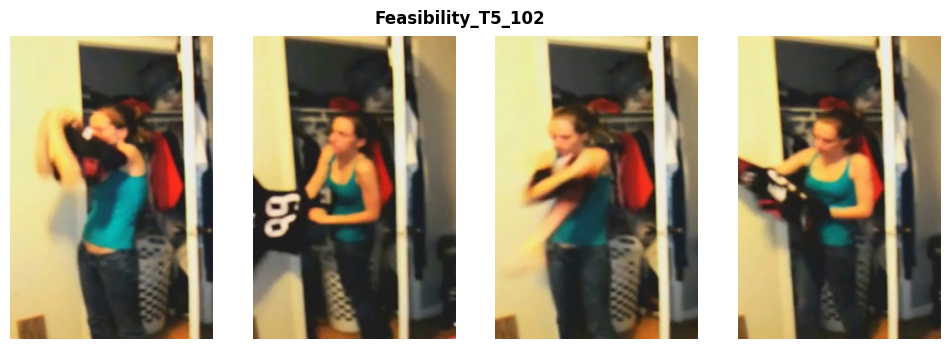

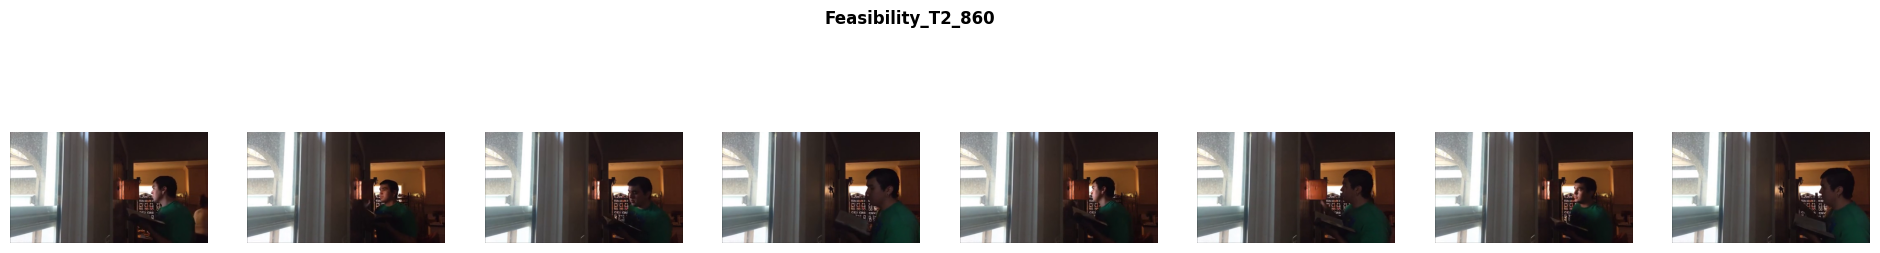

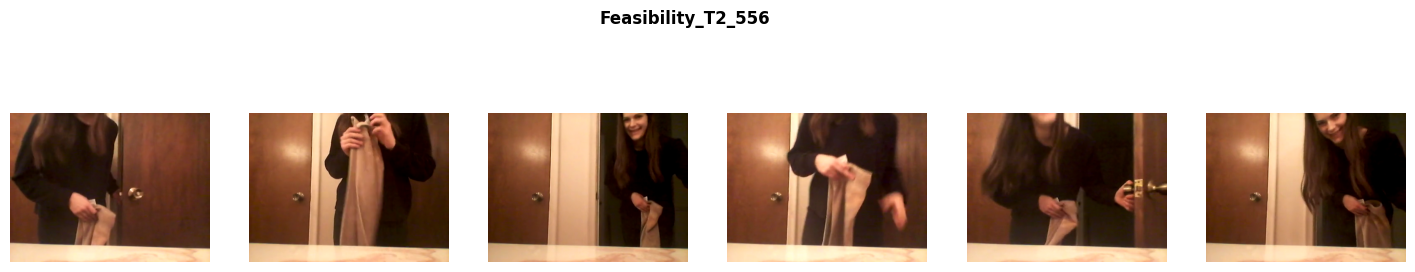

In [12]:
fps=1


for i, sample in enumerate(samples):
    question_id = sample['question_id']
    encodings = [
        frame['encoding'] for frame in video_tools.generate_video_frames(
            Path(RAW_VIDEO_DIR, f"{sample['video_id']}.mp4"),
            fps=fps,
            start=sample.get('start', None),
            end=sample.get('end', None),
        )
    ]

    fig, axs = plt.subplots(1, len(encodings), figsize=(3*len(encodings), 4))
    
    # Add title above the row
    fig.subplots_adjust(top=0.88)
    fig.suptitle(
        question_id,
        fontsize=12.0,
        fontweight='bold',
        y=0.94
    )
    
    for img, ax in zip(encodings, axs):
        img = base64.b64decode(img)
        image = PIL.Image.open(io.BytesIO(img))
        image_np = np.array(image)  # Convert to NumPy array for Matplotlib
        ax.imshow(image_np)
        ax.axis('off')

plt.axis('off')  # Hide axes
plt.show()


In [13]:
payload = main.img_payload(
    client.ollama_params,
    samples[0],
    RAW_VIDEO_DIR,
    fps,
    max_frames=None,
    batch_images=True
)

print(payload[0]['payload']['messages'][0]['content'])


=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/ATV2F.mp4 with start: 0.0, end: 4.0, fps: 1, max_frames: None
=[INFO] :- 
Video: ATV2F
=[INFO] :-  - interval: 0.0-4.0
=[INFO] :-  - 4 frames.
=[DEBUG] :- The prompt is:
You are an intelligent video comprehension model. You will receive as input:
- A sequence of images (frames) extracted from a video
- A question about the video

Your task is not to answer the question but to analyze and describe the scene in enough detail such that your description alone is enough to answer the question, even if the images themselves are not available.
In generating your description, follow these guidelines:


1. Look for recurring objects;
2. Note that the same object may look different across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same ob

You are an intelligent video comprehension model. You will receive as input:
- A sequence of images (frames) extracted from a video
- A question about the video

Your task is not to answer the question but to analyze and describe the scene in enough detail such that your description alone is enough to answer the question, even if the images themselves are not available.
In generating your description, follow these guidelines:


1. Look for recurring objects;
2. Note that the same object may look different across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interact with its environment;
4. Understand the directional movement of the people and objects;
5. Carefully analyze the chronological sequence of the events;
6. Pay attention to the atomic and fine-grained movement, pose and ac

In [14]:
if False:
    main.stream_sgg(
        ollama_client=client,
        dataset=samples,
        reply=follow_up,
        videos_dir=RAW_VIDEO_DIR,
        fps=fps,
        output_filepath=WORK_DIR / 'notebooks/sgg_qbias_test.jsonl',
        max_frames=None,
        batch_images=True
    
        
    )


In [302]:
SGG_QBIAS_PATH = WORK_DIR / "outputs/sgg/sggm_qbias_alt1_gemma3:4b-it-qat_20250707_21:59:00.jsonl"
sgg_qbias = pd.read_json(SGG_QBIAS_PATH, lines=True)
sgg_qbias.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039 entries, 0 to 1038
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   question_id   1039 non-null   object
 1   chat_history  1039 non-null   object
 2   stsg          1039 non-null   object
dtypes: object(3)
memory usage: 24.5+ KB


In [303]:
sgg_qbias.head()


,question_id,chat_history,stsg
0,Feasibility_T5_102,"[{'role': 'user', 'content': 'You are an intel...",Here’s the spatio-temporal scene graph based o...
1,Feasibility_T2_860,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...
2,Feasibility_T2_556,"[{'role': 'user', 'content': 'You are an intel...","Okay, here’s a spatio-temporal scene graph rep..."
3,Prediction_T1_2539,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...
4,Prediction_T4_1253,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...


In [121]:
mss = []
j = 0
for i in range(star_small_df.shape[0]):
    vid = star_small_df.iloc[i]['video_id']
    qid = sgg_qbias.iloc[j]['qid']
    
    if qid != vid:
        print(f"Mismatch at {i}: qid={qid!r} vs video_id={vid!r}")
        mss.append(i)
        continue
    j += 1
    

Mismatch at 105: qid='Z97SD' vs video_id='MA15X'
Mismatch at 315: qid='M1TZR' vs video_id='MA15X'
Mismatch at 330: qid='HL5OP' vs video_id='MA15X'
Mismatch at 616: qid='EO6OI' vs video_id='STAFD'
Mismatch at 746: qid='GTK8W' vs video_id='MA15X'
Mismatch at 748: qid='L7HA6' vs video_id='MA15X'
Mismatch at 831: qid='FTG07' vs video_id='AFTMI'
Mismatch at 843: qid='320ZB' vs video_id='GPR89'
Mismatch at 932: qid='DR7K0' vs video_id='MA15X'
